In [1]:
import pandas as pd

df = pd.read_csv("../spotify.csv")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

df['is_hit'] = df['popularity'] >= 60
y_hit = df['is_hit'].astype(int)

X = df.drop(columns=['track_id', 'artists', 'album_name', 'track_name', 'track_genre', 'is_hit', 'popularity'])

X_train, X_test, y_train, y_test = train_test_split(X, y_hit, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Flop", "Hit"]))

              precision    recall  f1-score   support

        Flop       0.84      0.88      0.86       725
         Hit       0.84      0.79      0.82       569

    accuracy                           0.84      1294
   macro avg       0.84      0.84      0.84      1294
weighted avg       0.84      0.84      0.84      1294



In [7]:
print(df['is_hit'].value_counts())
print(df['is_hit'].value_counts(normalize=True))

is_hit
False    3765
True     2703
Name: count, dtype: int64
is_hit
False    0.582096
True     0.417904
Name: proportion, dtype: float64


In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    clf,
    X,
    y_hit,
    cv=cv,
    scoring='f1_weighted'
)

print(scores)
print(scores.mean())

[0.8433698  0.85857232 0.85212979 0.84370965 0.84778068]
0.8491124488424304


In [4]:
import pandas as pd

feature_importance = pd.Series(
    clf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Unnamed: 0          0.296999
loudness            0.084595
valence             0.080933
energy              0.066554
tempo               0.065802
danceability        0.063664
acousticness        0.062970
duration_ms         0.060945
instrumentalness    0.057841
speechiness         0.057397
liveness            0.049719
key                 0.029729
explicit            0.009082
mode                0.009074
time_signature      0.004698
dtype: float64


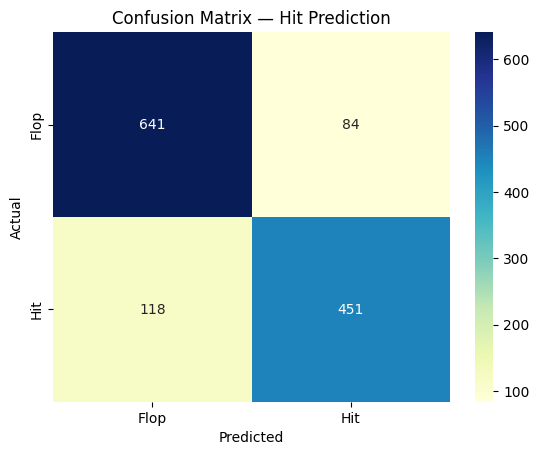

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=["Flop", "Hit"], yticklabels=["Flop", "Hit"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Hit Prediction")
plt.show()

In [6]:
df_copy = df.copy()
feature_cols = df_copy.drop(columns=['track_id', 'artists', 'album_name', 'track_name', 'track_genre', 'is_hit', 'popularity']).columns

song_input = input("Enter song name: ").strip().lower()

matches = df_copy[df_copy['track_name'].str.lower() == song_input]

if matches.empty:
    print("Song not found in the dataset.")
else:
    if len(matches) > 1:
        print("Multiple versions of the song found:")
        for i, row in matches.iterrows():
            print(f"- {row['track_name']} by {row['artists']}")

        artist_input = input("Enter artist name to match: ").strip().lower()
        filtered = matches[matches['artists'].str.lower().str.contains(artist_input)]

        if filtered.empty:
            print("No match for that artist.")
        else:
            song_row = filtered.iloc[0]
    else:
        song_row = matches.iloc[0]

    if 'song_row' in locals():
        song_features = song_row[feature_cols].values.reshape(1, -1)

        pred = clf.predict(song_features)[0]
        prob = clf.predict_proba(song_features)[0][1]

        result = "Hit" if pred == 1 else "Flop"
        print(f"\nSong: {song_row['track_name']} — {song_row['artists']}")
        print(f"Prediction: {result}")
        print(f"Confidence (Hit Probability): {prob:.2f}")


Song not found in the dataset.
